In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
import emcee
import os
from multiprocessing import Pool
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

In [2]:
#%matplotlib widget
#plt.close('all')

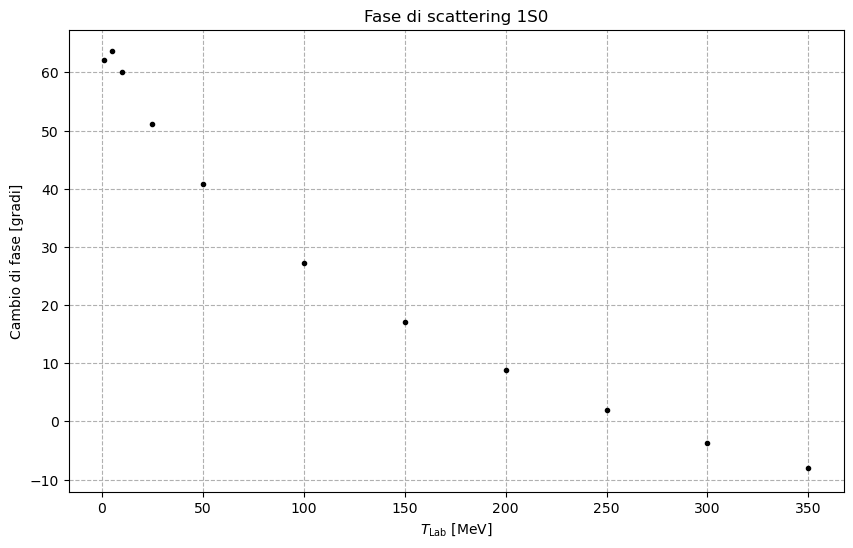

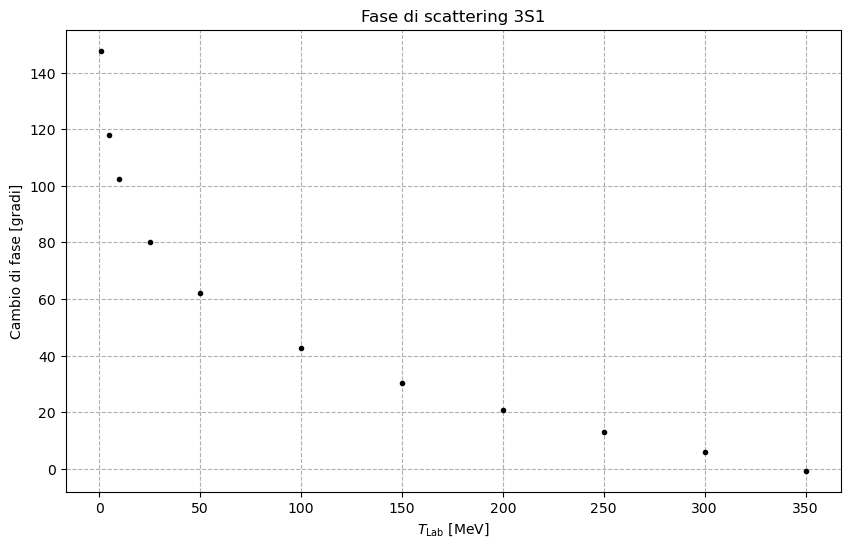

In [3]:
# plot dati LO
T_Lab = granada.Tlabs # sempre queste per tutte le serie
# In approssimazione LO, ci sono le onde 1S0 e 3S1 e solo quelle!
shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors
shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

plt.figure(figsize=(10, 6))
plt.errorbar(T_Lab, shift_1S0, yerr = shift_1S0_error, label = "Dati sperimentali", color="k", ls="none", marker="o", markersize=3.)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"Cambio di fase [gradi]")
plt.title("Fase di scattering 1S0")
plt.grid(linestyle = "--")
plt.show()

plt.figure(figsize=(10, 6))
plt.errorbar(T_Lab, shift_3S1, yerr = shift_3S1_error, label = "Dati sperimentali", color="k", ls="none", marker="o", markersize=3.)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"Cambio di fase [gradi]")
plt.title("Fase di scattering 3S1")
plt.grid(linestyle = "--")
plt.show()
# Errori ci sono ma così piccoli da non vedersi

In [4]:
########## Penso l'inferenza vada fatta su e SOLO su i dati di scattering, essendo quelli a noi forniti ######################
#def calcola_energia_deuterone(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite',
#                              ordine_potenziale='LO', Lambda=500.0, lecs=None):
#    """
#    Calcola l'autovalore di energia (stato fondamentale) del deuterone.
#    Restituisce l'energia e la funzione d'onda corrispondente.
#    """
#    nn = nn_studio.nn_studio(jmin=jmin, jmax=jmax, tzmin=tzmin, tzmax=tzmax, Np=Np, mesh_type=mesh_type)
#    potential = chiral_potential.two_nucleon_potential(ordine_potenziale, Lambda=Lambda)
#    nn.V = potential
#
#    if lecs is None:
#        input_lecs = lec_values.lo_lecs
#    else:
#        input_lecs = lecs
#    nn.lecs = input_lecs.copy()
#
#    _, deuteron_channel = nn.lookup_channel_idx(l=0, ll=2, s=1, j=1)
#    _, mu = nn.lab2rel(0, 0)
#    N = 2 * (nn.Np)
#    H = np.zeros((N, N))
#    T = np.zeros((N, N))
#    ww = np.hstack((nn.wmesh, nn.wmesh))
#    pp = np.hstack((nn.pmesh, nn.pmesh))
#    V = nn.setup_Vmtx(deuteron_channel[0])[0]
#
#    for i, p_bra in enumerate(pp):
#        for j, p_ket in enumerate(pp):
#            Tij = 0
#            if i == j:
#                Tij = p_bra ** 2 / (2 * mu)
#                T[i][j] = Tij
#            V[i][j] = V[i][j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])
#    H = T + V
#
#    eigvals, eigvecs = linalg.eigh(H)
#    s = np.argsort(eigvals)
#    E = eigvals[s[0]]
#    psi_k = eigvecs[:, s[0]]
#    return E, psi_k

In [5]:
# Nell'interazione 3S1 entra in gioco solo la C_3S1, mentre nell'interazione 1S0 entra in gioco solo la C_1S0
# Il fastidio è che fare una delle due interazioni dobbiamo comunque inizializzare nn_studio con entrambe le costanti
# I due prior sono indipendenti, ma nota che abbiamo anche due likelihood indipendenti! Ed infatti due diversi dataset

def ln_prior_LO(parameters):
    C_1S0, C_3S1 = parameters
    
    avg_1S0 = 0.0
    avg_3S1 = 0.0
    sigma_1S0 = 5.0
    sigma_3S1 = 5.0

    ln_P_1S0 = -0.5 * ( np.log(2*np.pi * sigma_1S0**2) + ((C_1S0-avg_1S0) / sigma_1S0)**2 )
    ln_P_3S1 = -0.5 * ( np.log(2*np.pi * sigma_3S1**2) + ((C_3S1-avg_3S1) / sigma_3S1)**2 )
    return ln_P_1S0 + ln_P_3S1

def ln_likelihood_LO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1):
    LO_lecs = {}
    LO_lecs["C_1S0"] = parameters[0]
    LO_lecs["C_3S1"] = parameters[1]
    nnstudio.lecs = LO_lecs
    
    nnstudio.compute_Tmtx(chn_1S0, verbose=False)
    teo_1S0 = nnstudio.phase_shifts[0]
    nnstudio.compute_Tmtx(chn_3S1, verbose=False)
    teo_3S1 = nnstudio.phase_shifts[0][:,0]
    
    ln_L_1S0 = -0.5 * np.sum( np.log(2*np.pi * err_1S0**2) + ((exp_1S0-teo_1S0) / err_1S0)**2 )
    ln_L_3S1 = -0.5 * np.sum( np.log(2*np.pi * err_3S1**2) + ((exp_3S1-teo_3S1) / err_3S1)**2 )
    return ln_L_1S0 + ln_L_3S1

def ln_posterior_LO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1):
    return ln_prior_LO(parameters) + ln_likelihood_LO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1)

# In totale, il teo. di Bayes in forma log è la somma di due prior e di due likelihood!

In [6]:
# Inizializziamo nn_studio: l'inferenza per com'è scritta presume che Tlabs e V siano già stati selezionati:
nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=10, mesh_type="gauleg_finite")
nn.Tlabs = T_Lab
nn.V = chiral_potential.two_nucleon_potential("LO",Lambda=500.0)
_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) # Il canale 1S0 è il primo orbitale anti-legante! (spin accoppiati, chn_idx=0)
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale 3S1 è quello del ground state del deutone

In [7]:
# Metodo MCMC:
ndim = 2
nwalkers = 5
nsteps = 500

initial_guess = [-0.10, -0.10]
starting_positions = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, 
            ndim, 
            ln_posterior_LO, 
            args=(nn, channel_1S0, shift_1S0, shift_1S0_error, channel_3S1, shift_3S1, shift_3S1_error),
            pool=None
        )
        print(f"Multithreading on {ncpu} cores...")
        sampler.run_mcmc(starting_positions, nsteps, progress=True)
    print("Done!")

Multithreading on 8 cores...


100%|██████████| 500/500 [19:24<00:00,  2.33s/it]


Done!


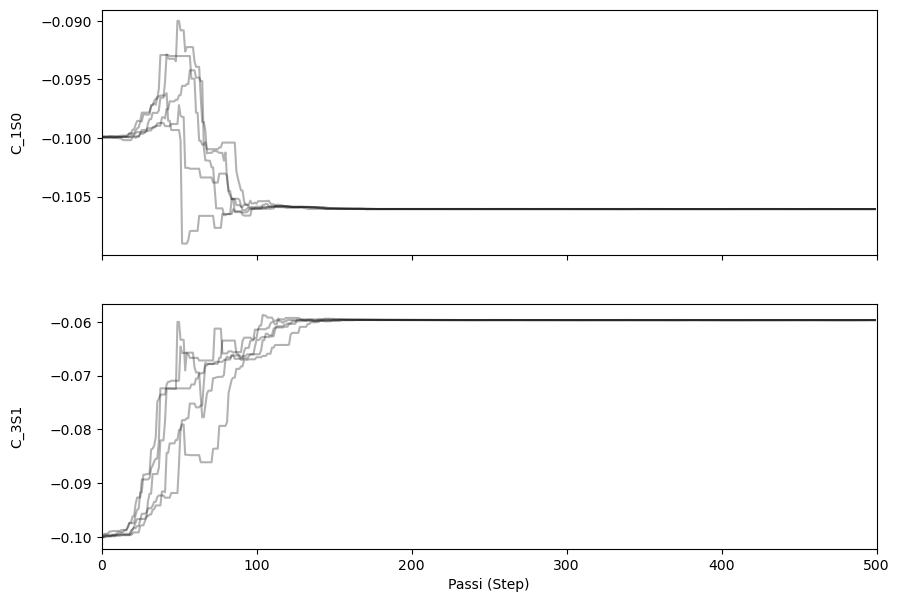

In [8]:
# Verifica della convergenza:
samples = sampler.get_chain()
labels = ["C_1S0", "C_3S1"]
figure, axes = plt.subplots(2, figsize=(10, 7), sharex=True)

for i in range(2):
    inset = axes[i]
    inset.plot(samples[:, :, i], "k", alpha=0.3)
    inset.set_xlim(0, len(samples))
    inset.set_ylabel(labels[i])
    inset.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Passi (Step)")
plt.show()

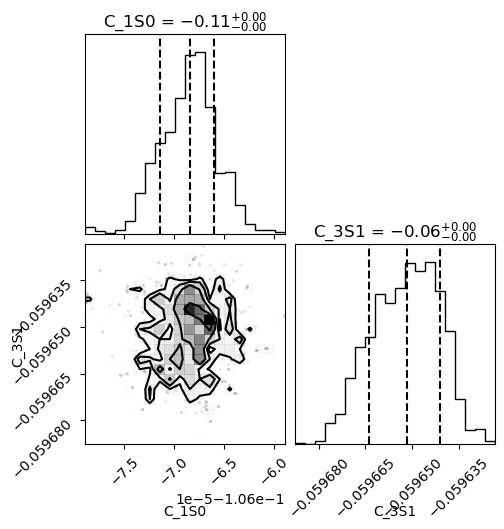

In [9]:
# corner plot
campioni = sampler.get_chain(discard=200, flat=True)

nomi_parametri = ["C_1S0", "C_3S1"]

fig = corner.corner(
    campioni, 
    labels=nomi_parametri,
    quantiles=[0.16, 0.5, 0.84], # Mostra i limiti di 1 deviazione standard
    show_titles=True,            # Stampa i valori (mediana +/- sigma) sopra ogni colonna!
    title_kwargs={"fontsize": 12}
)

plt.show()

In [16]:
# estraggo la deviazione standard dai campioni:
C_1S0_median = np.median(campioni[:, 0])
C_1S0_sigma = 0.5 * (np.percentile(campioni[:, 0], 84) - np.percentile(campioni[:, 0], 16))
C_3S1_median = np.median(campioni[:, 1])
C_3S1_sigma = 0.5 * (np.percentile(campioni[:, 1], 84) - np.percentile(campioni[:, 1], 16))

print(C_3S1_sigma)

1.1379515014845604e-05


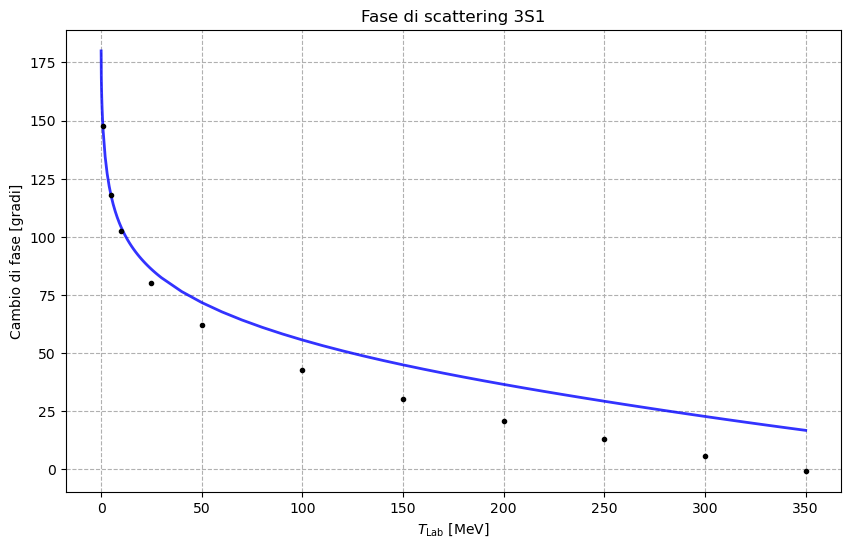

Valore ottenuto per C_1S0 in approssimazione LO: -0.106070	(valore nominale: -0.106271)
Valore ottenuto per C_3S1 in approssimazione LO: -0.059642	(valore nominale: -0.062079)


In [18]:
# Verifica sovrapposizione coi dati sperimentali:
C_1S0 = samples[-1, 0, 0]
C_3S1 = samples[-1, 0, 1]

# Ripetiamo le operazioni dello script di esempio, ma coi nostri valori per le lecs:
nn.Tlabs = [1e-6] + [x/10 for x in np.arange(1,11,1)]+[x for x in np.arange(2,31,1)] + [x for x in np.arange(40,360,10)]
LO_lecs = {}
LO_lecs["C_1S0"] = C_1S0
LO_lecs["C_3S1"] = C_3S1
nn.lecs = LO_lecs
_, selected_channel = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1)
nn.compute_Tmtx(selected_channel,verbose=False)
shift_teorico = nn.phase_shifts[0][:,0]

plt.figure(figsize=(10, 6))
plt.errorbar(T_Lab, shift_3S1, yerr = shift_3S1_error, label = "Dati sperimentali", color="k", ls="none", marker="o", markersize=3.)
plt.plot(nn.Tlabs, shift_teorico, label = r"$\chi$EFT LO ($\Lambda=500$ MeV)",color="blue",alpha=0.8,lw=2)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"Cambio di fase [gradi]")
plt.title("Fase di scattering 3S1")
plt.grid(linestyle = "--")
plt.show()

print(f"Valore ottenuto per C_1S0 in approssimazione LO: {C_1S0:.6f}\t(valore nominale: {lec_values.lo_lecs["C_1S0"]:.6f})")
print(f"Valore ottenuto per C_3S1 in approssimazione LO: {C_3S1:.6f}\t(valore nominale: {lec_values.lo_lecs["C_3S1"]:.6f})")